# Name - Anushka Suresh Salvi
# Roll No - 51
# PRN No - 1252090036
# DIV - SEDA BATCH-2
# Assignment-11

Title: Assignment on Classification technique. Every year many students give the GRE exam to get admission in foreign Universities. The data set contains GRE Scores (out of 340), TOEFL Scores (out of 120), University Rating (out of 5), Statement of Purpose strength (out of 5), Letter of Recommendation strength (out of 5), Undergraduate GPA (out of 10), Research Experience (0=no, 1=yes), Admitted (0=no, 1=yes). Admitted is the target variable.

The counsellor of the firm is supposed check whether the student will get an admission or not based on his/her GRE score and Academic Score. So to help the counsellor to make appropriate decisions, build a machine learning model classifier using a Decision tree to predict whether a student will get admission or not.  Apply Data pre-processing (Label Encoding, Data Transformation….) techniques if necessary.

Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
from sklearn import tree
import matplotlib.pyplot as plt



Dataset Description

The dataset contains the following attributes:

GRE Score (out of 340)

TOEFL Score (out of 120)

University Rating (1–5)

SOP (Statement of Purpose strength)

LOR (Letter of Recommendation strength)

CGPA (out of 10)

Research (0 = No, 1 = Yes)

Admitted (Target Variable: 0 = No, 1 = Yes)



In [ ]:
df=pd.read_csv("Admission_Predict.csv")
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,0.82
396,397,325,107,3,3.0,3.5,9.11,1,0.84
397,398,330,116,4,5.0,4.5,9.45,1,0.91
398,399,312,103,3,3.5,4.0,8.78,0,0.67


Data Preprocessing
Remove unnecessary columns

Converted target variable into binary

In [ ]:
df.drop(columns=["Serial No."], inplace=True, errors='ignore')

if 'Chance of Admit ' in df.columns:
  df['Admitted'] = (df['Chance of Admit '] >=0.5).astype(int)
  df.drop(columns=['Chance of Admit '], inplace=True)

print("Missing Values:\n", df.isnull().sum())



Missing Values:
 GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Admitted             0
dtype: int64


DECISION TREE:
A Decision Tree is a supervised machine learning algorithm used for classification and regression tasks. It works like a tree structure where data is split based on conditions.

The algorithm selects the best feature to split the data
It uses measures like:
Gini Index
Entropy (Information Gain)
It keeps splitting until:
Data is pure OR
Stopping condition is met

In [ ]:
X=df.drop("Admitted", axis=1)
y= df["Admitted"]

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

model=DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred=model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8875

Confusion Matrix:
 [[ 4  6]
 [ 3 67]]

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.40      0.47        10
           1       0.92      0.96      0.94        70

    accuracy                           0.89        80
   macro avg       0.74      0.68      0.70        80
weighted avg       0.87      0.89      0.88        80



CGPA is the most important factor — students with high CGPA (above ~8) have a very high chance of admission.

GRE score supports the decision — higher GRE can improve chances, especially when CGPA is moderate.

Other factors (LOR, TOEFL, Research) have less impact and only influence decisions in specific cases.

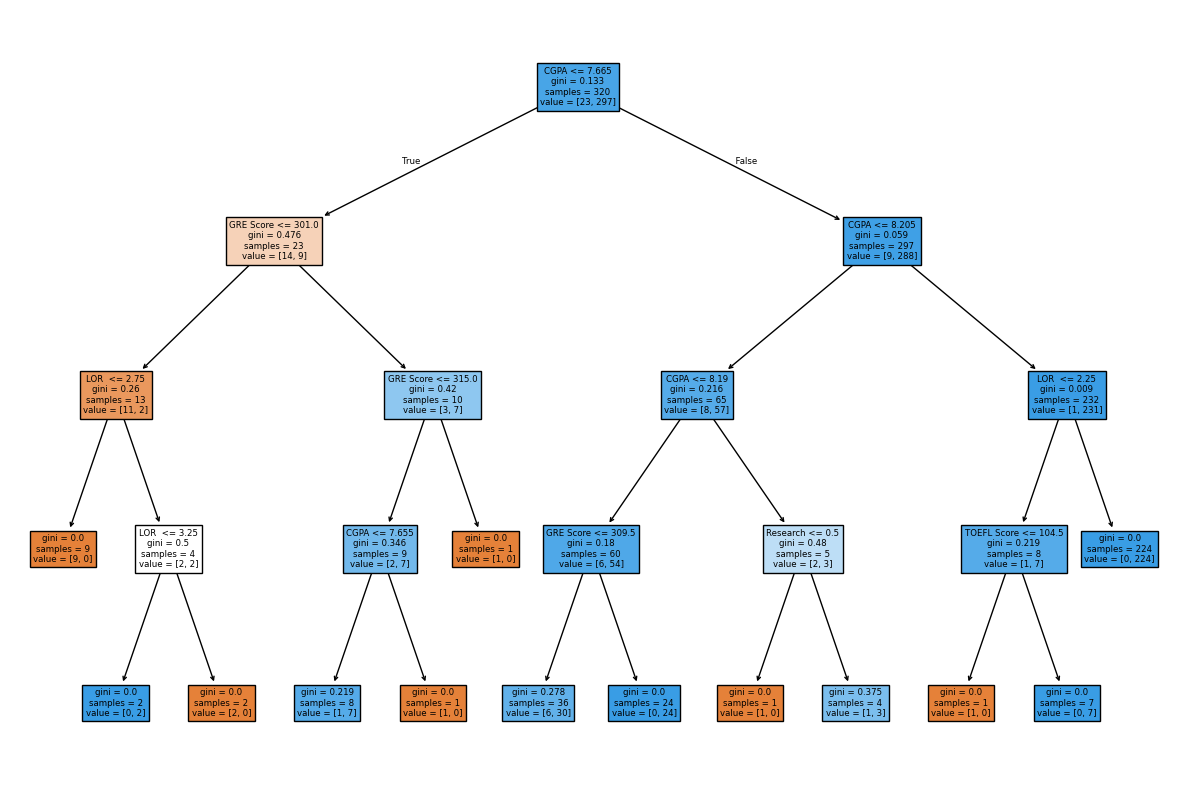

In [ ]:
plt.figure(figsize=(15,10))
tree.plot_tree(model, filled=True, feature_names=X.columns)
plt.show()
